# Below is the Model for Single Feature House Price Prediction

In [208]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score
import numpy as np
import os
import kagglehub
# %load_ext cudf.pandas
from kagglehub import KaggleDatasetAdapter


In [ ]:
# Set the name of the file within the Kaggle dataset you'd like to load
file_name_in_dataset = "housing_price_dataset.csv"

# Load the latest version
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"ameyac11/housing-price-prediction-dataset",file_name_in_dataset)


100%|██████████| 7.43M/7.43M [00:02<00:00, 3.02MB/s]


,property_id,city,locality,locality_tier,property_type,bhk,bathrooms,balconies,built_up_area,carpet_area,...,power_backup,lift_available,maintenance_fee_monthly,distance_to_city_center_km,distance_to_metro_km,nearby_schools,nearby_hospitals,transaction_type,price_in_lakhs,price_category
0,PROP-000001,Bangalore,HSR Layout,Standard,Apartment,4,4,1,1570,1361,...,1,0,3094,11.6,3.5,3,1,New,102.34,Low
1,PROP-000002,Mumbai,Powai,Standard,Row House,2,1,1,908,778,...,1,1,3893,24.2,1.3,3,2,Resale,71.48,Low
2,PROP-000003,Bangalore,Indiranagar,Premium,Independent House,3,3,2,1784,1568,...,1,1,7038,5.0,0.1,2,1,Resale,245.57,High
3,PROP-000004,Mumbai,Powai,Standard,Independent House,4,4,2,2318,2011,...,0,1,3569,11.9,7.9,2,0,New,122.95,Low
4,PROP-000005,Bangalore,Electronic City,Standard,Apartment,3,4,2,988,840,...,1,1,2628,11.4,7.2,1,0,Resale,64.71,Low


In [205]:
filter_data = df[["city", "locality_tier", "property_type", "bhk", "bathrooms",
    "balconies", "built_up_area", "carpet_area", "floor_number", "total_floors",
    "floor_category", "facing", "furnishing_status", "property_age", "parking_spaces",
    "swimming_pool", "lift_available", "distance_to_city_center_km", "transaction_type", "price_in_lakhs", "price_category"]]

categorical_encoder = OrdinalEncoder(
    categories=[
        ['Studio', 'Apartment', 'Row House', 'Independent House', 'Villa', 'Penthouse'],  # property_type
        ['Ground', 'Low (1-4)', 'Mid (5-9)', 'High (10-19)', 'Top (20+)'],               # floor_category
        ['Unfurnished', 'Semi-Furnished', 'Fully Furnished'],                             # furnishing_status
        ['Resale', 'New'],                                                                # transaction_type
        ['Affordable', 'Standard', 'Premium'],                                          # locality_tier
        ["Low", "High"]
    ]
)

cols = [
    'property_type',
    'floor_category',
    'furnishing_status',
    'transaction_type',
    'locality_tier',
    "price_category"
]

one_hot_encoder = OneHotEncoder(drop='first',handle_unknown='ignore', sparse_output=False)
for col in ["city", "property_type", "facing"]:
    X_encoded  = one_hot_encoder.fit_transform(filter_data[[col]])
    onehot_encoder_dataframe = pd.DataFrame(data =X_encoded, columns = one_hot_encoder.get_feature_names_out().tolist())
    filter_data = pd.concat([filter_data, onehot_encoder_dataframe], axis= 1 )

filter_data[cols] = categorical_encoder.fit_transform(filter_data[cols])
filter_data.drop(columns= ["city", "facing"],  inplace=True)
filter_data.head(3)


,locality_tier,property_type,bhk,bathrooms,balconies,built_up_area,carpet_area,floor_number,total_floors,floor_category,...,property_type_Row House,property_type_Studio,property_type_Villa,facing_North,facing_North-East,facing_North-West,facing_South,facing_South-East,facing_South-West,facing_West
0,1.0,1.0,4,4,1,1570,1361,0,3,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,2.0,2,1,1,908,778,9,17,2.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2.0,3.0,3,3,2,1784,1568,14,16,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [220]:

X = filter_data.drop(columns=["price_in_lakhs"])
y = filter_data["price_in_lakhs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("lr", LinearRegression())
])
poly_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=500, max_depth=20, min_samples_leaf=2, min_samples_split=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train,y_train)

y_pred_Linear_Regression = model.predict(X_test)
y_pred_Polynomial = poly_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
# filter_data["Predicted_Price"] = y_pred
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_Linear_Regression))
print("Linear Regression R²:", r2_score(y_test, y_pred_Linear_Regression))

print("\nPolynomial Regression MAE:", mean_absolute_error(y_test, y_pred_Polynomial))
print("Polynomial Regression R²:", r2_score(y_test, y_pred_Polynomial))

print("\nRandomForest Regressor MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RandomForest Regressor R²:", r2_score(y_test, y_pred_rf))

scores = cross_val_score(rf_model, X, y, cv=5, scoring="r2", n_jobs=-1)
print("\nRandomForest Regressor Fold Scores:", scores)
print("RandomForest Regressor Mean R²:", scores.mean())
print("RandomForest Regressor Std:", scores.std())


Linear Regression MAE: 28.094916575790894
Linear Regression R²: 0.8658018693696198

Polynomial Regression MAE: 24.215907999958
Polynomial Regression R²: 0.8986669039669476

RandomForest Regressor MAE: 23.57165277166122
RandomForest Regressor R²: 0.9007667346336843


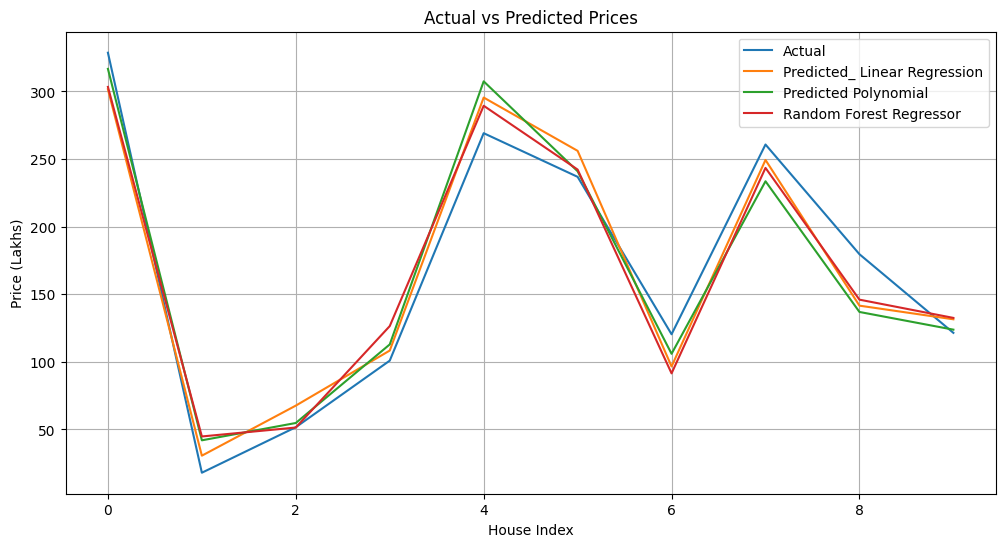

In [160]:
y_test_plot = y_test.reset_index(drop=True)

plt.figure(figsize=(12,6))
plt.plot(y_test_plot[:10], label='Actual')
plt.plot(y_pred_Linear_Regression[:10], label='Predicted_ Linear Regression')
plt.plot(y_pred_Polynomial[:10], label='Predicted Polynomial')
plt.plot(y_pred_rf[:10], label='Random Forest Regressor')

plt.xlabel('House Index')
plt.ylabel('Price (Lakhs)')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.grid(True)

plt.show()